In [1]:
import numpy as np
import struct
from array import array
from os.path import join

In [2]:
class ReadMNISTDataset(object):

    def __init__(self, training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath):

        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def readImagesLabels(self, images_filepath, labels_filepath):

        labels = []
        with open(labels_filepath, "rb") as file:    
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('magic number error: expected 2049, got {}'.format(magic))
            labels = array('B', file.read())
        
        with open(images_filepath, "rb") as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('magic number error: expected 2051, got {}'.format(magic))
            image_data = array('B', file.read())

        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels

    def load_data(self):
        x_train, y_train = self.readImagesLabels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.readImagesLabels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test) 

In [3]:
input_path = '../input'
training_images_filepath = join(input_path, 'train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels.idx1-ubyte')

In [4]:
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

In [6]:
data_loader = ReadMNISTDataset(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)

In [7]:
(x_train, y_train), (x_test, y_test) = data_loader.load_data()

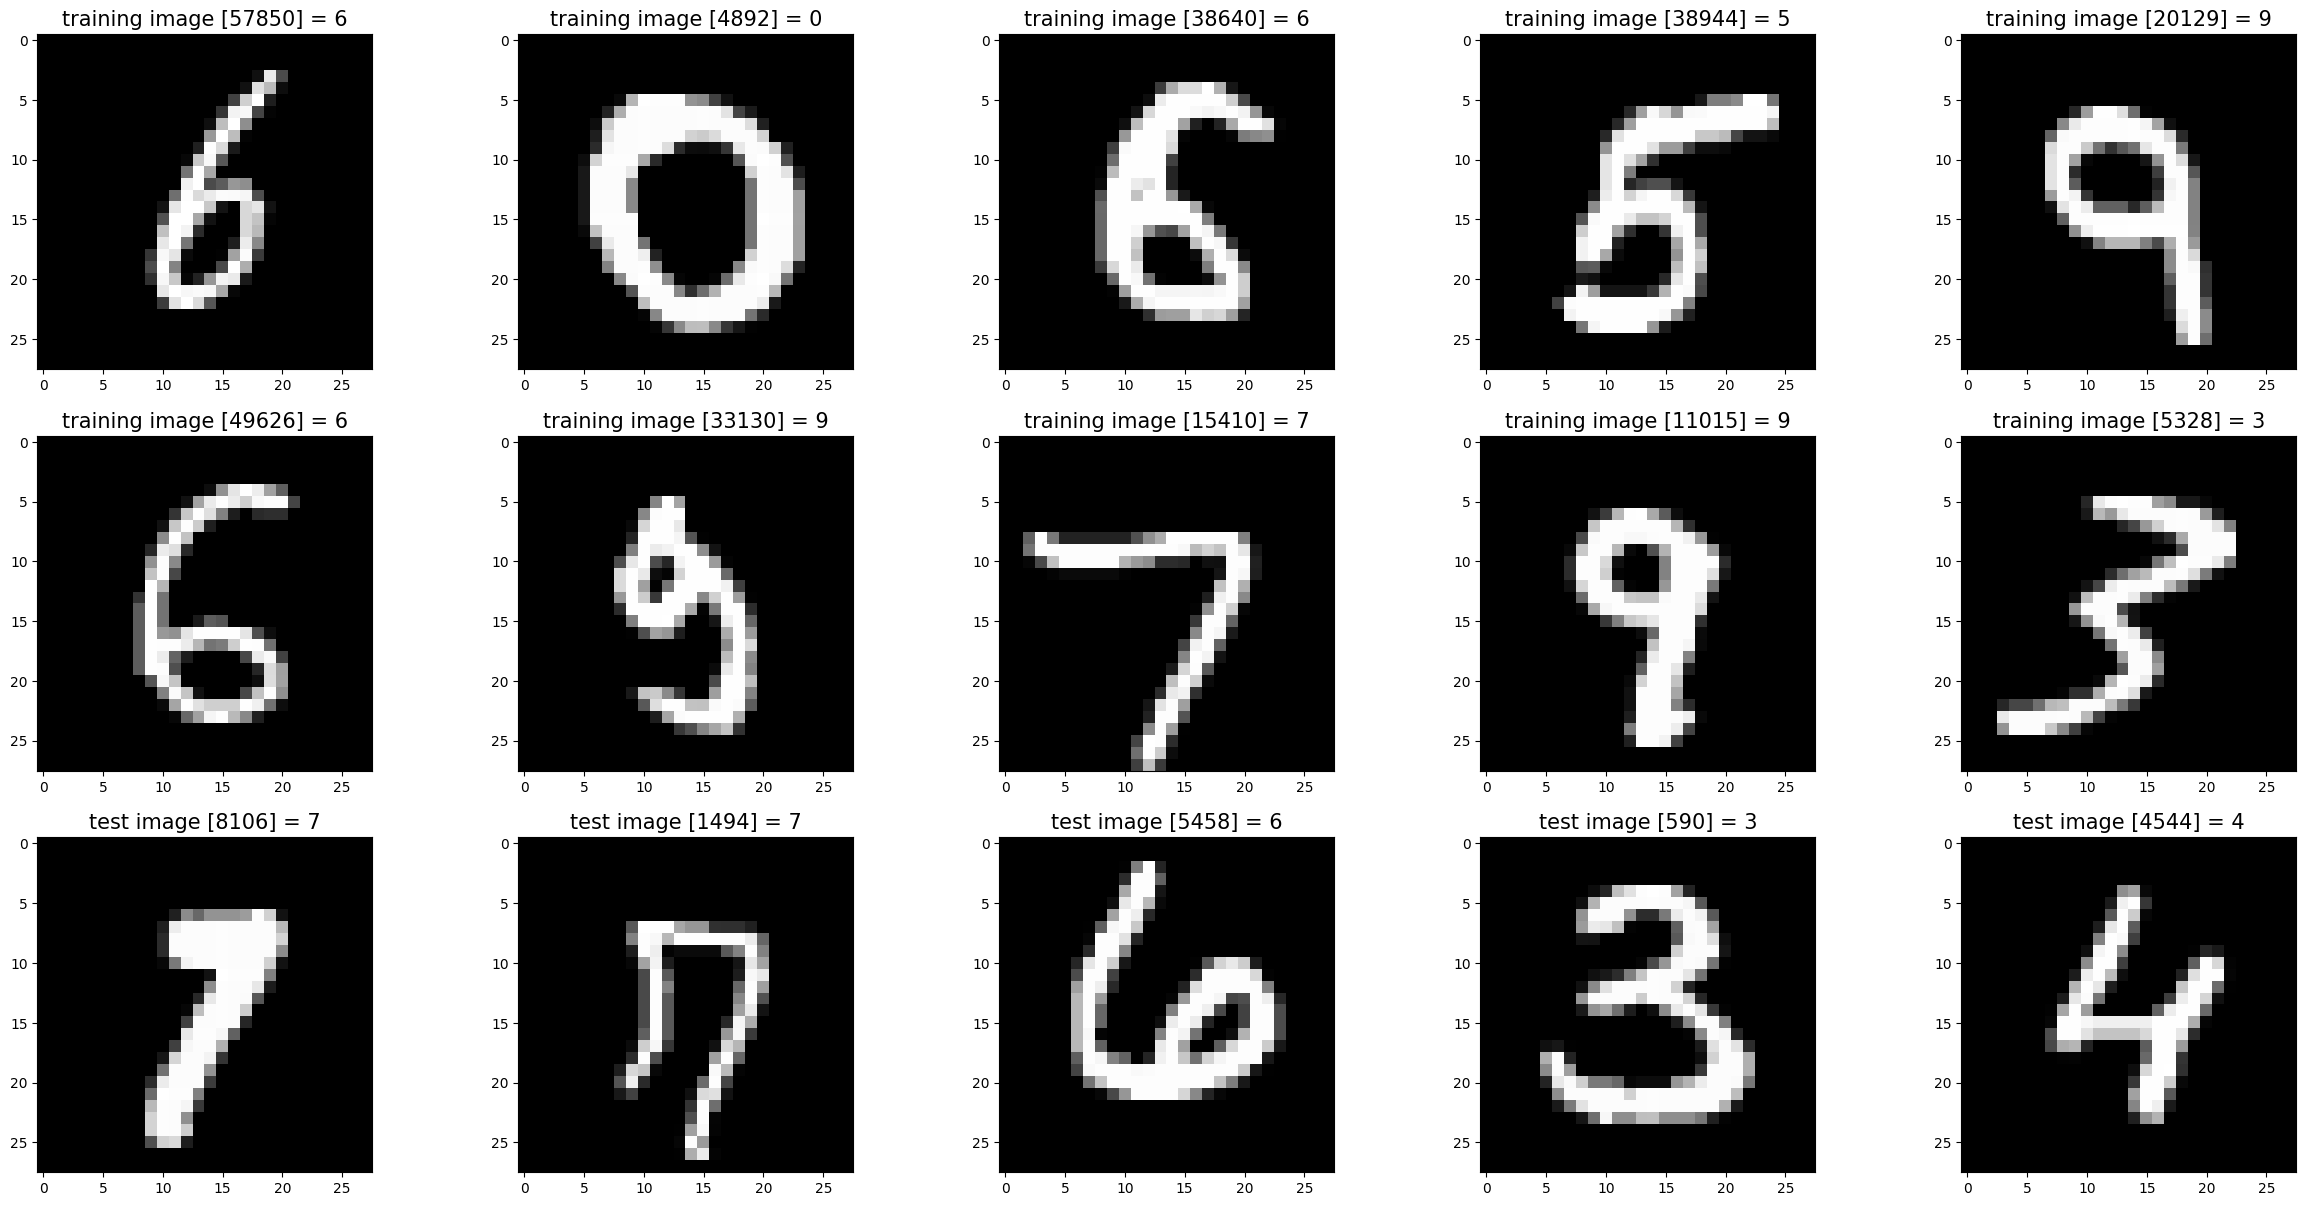

In [8]:
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [9]:
from PIL import Image
import PIL

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import transforms

In [10]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [11]:
class GetDataset(torch.utils.data.Dataset):

    def __init__(self, transform, images, labels):
        self.transform = transform
        self.images = np.array(images, dtype=np.uint8)
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.transform(Image.fromarray(self.images[idx], mode="L"))
        label = self.labels[idx]

        return (image, label)

In [12]:
train_dataset = GetDataset(transform, x_train, y_train)
test_dataset = GetDataset(transform, x_test, y_test)

In [13]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

In [14]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [15]:
class NeuralNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 120, kernel_size=5),
            nn.ReLU(),
            
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )
        
    def forward(self, x):
        return self.network(x)

In [16]:
network = NeuralNet()
loss_function = nn.CrossEntropyLoss()
optimiser = optim.SGD(network.parameters(), lr=0.001, momentum=0.9)

In [17]:
for epoch in range(10):
    print(f'training epoch: {epoch}')

    running_loss = 0.0

    for i, data in enumerate(train_dataloader):
        images, labels = data

        optimiser.zero_grad()

        out = network(images)

        loss = loss_function(out, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    print(f'Loss: {running_loss / len(train_dataloader):.4f}')

training epoch: 0
Loss: 1.1990
training epoch: 1
Loss: 0.1987
training epoch: 2
Loss: 0.1261
training epoch: 3
Loss: 0.0978
training epoch: 4
Loss: 0.0823
training epoch: 5
Loss: 0.0710
training epoch: 6
Loss: 0.0626
training epoch: 7
Loss: 0.0559
training epoch: 8
Loss: 0.0500
training epoch: 9
Loss: 0.0464


In [18]:
torch.save(network.state_dict(), 'trained_net.pth')

In [19]:
net = NeuralNet()
net.load_state_dict(torch.load('trained_net.pth'))

<All keys matched successfully>

In [20]:
correct = 0
total = 0

net.eval()

with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'Accuracy: {accuracy}%')

Accuracy: 98.69%


In [21]:
def load_image(image_path):
    image = Image.open(image_path)
    image = transform(image)
    image = image.unsqueeze(0)
    return image

In [22]:
images_path = '../photoexamples'
images = ['img_11.jpg']
images = [join(images_path, image) for image in images]
images = [load_image(image) for image in images]

In [23]:
net.eval()
with torch.no_grad():
    for image in images:
        output = net(image)
        _, predicted = torch.max(output, 1)
        print(f'Predicted: {predicted.item()}')

Predicted: 0
